In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ranksums  # Wilcoxon rank-sum (Mann–Whitney)

In [2]:
collapsed = pd.read_csv('KRAS_clust0_HIPPO_GSEA.csv')

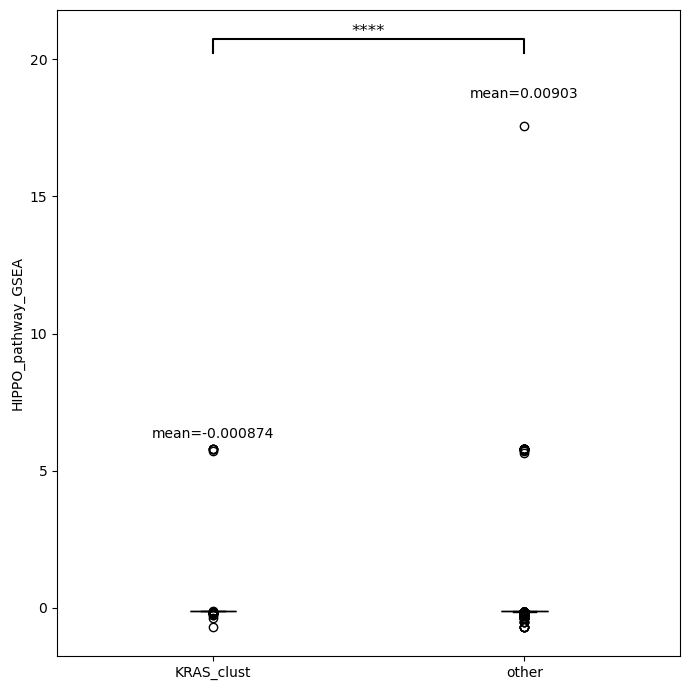

In [3]:
# ------------------------------
# Order groups and extract data
# ------------------------------
order = ['KRAS_clust' ,'other']

groups = [collapsed.loc[collapsed['kras_category'] == cat, 'norm_score'].dropna() for cat in order]

# ------------------------------
# Basic boxplot
# ------------------------------
plt.figure(figsize=(7, 7))
positions = np.arange(1, len(order) + 1)

bp = plt.boxplot(
    groups,
    labels=order,
    positions=positions,
    patch_artist=True,
    boxprops=dict(facecolor="#d8bfd8"),
    medianprops=dict(color="black")
)

plt.ylabel("HIPPO_pathway_GSEA")

# ------------------------------
# Add mean labels
# ------------------------------
for i, g in enumerate(groups, start=1):
    if len(g) > 0:
        mean_val = g.mean()
        plt.text(i, g.max() * 1.05, f"mean={mean_val:.3g}",
                 ha='center', va='bottom', fontsize=10)

# ------------------------------
# Significance testing
# ------------------------------
def p_to_star(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

# Pairs to test
pairs = [(0,1)]  # (KRAS_clust vs KRAS_other), etc.

# ------------------------------
# Significance bars
# ------------------------------
ymax = max([g.max() for g in groups if len(g) > 0]) * 1.15
y_step = (ymax * 0.10)  # vertical spacing

for j, (i1, i2) in enumerate(pairs):
    g1, g2 = groups[i1], groups[i2]
    if len(g1) == 0 or len(g2) == 0:
        continue

    stat, p = ranksums(g1, g2)
    label = p_to_star(p)

    x1, x2 = positions[i1], positions[i2]
    y = ymax + j * y_step
    h = y_step * 0.25

    # horizontal bar
    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    plt.text((x1 + x2) / 2, y + h, label, ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()
